# 14. Matplotlib 기본 차트

## 학습 목표
- Matplotlib 환경을 설정하고 한글 폰트를 적용할 수 있다
- `plot`, `bar`, `scatter`로 기본 차트를 그릴 수 있다
- `figsize`, `title`, `xlabel`, `ylabel`로 차트를 꾸밀 수 있다

---

## 왜 배워야 하나요?

숫자만 쭉 나열해서는 인사이트가 잘 안 보입니다. 시각화는:
- 추세와 패턴을 **한눈에** 보여주고
- 보고서/발표에서 **설득력**을 높이고
- 이상치를 **직관적으로** 탐지할 수 있게 합니다

Matplotlib는 Python 시각화의 **기본 라이브러리**이며, 대부분의 다른 라이브러리도 이 위에서 돌아갑니다.


In [1]:
# 한글 차트 나오도록 하는 라이브러리 설치
! pip install koreanize-matplotlib

   ---------------------------------------- 0.0/7.9 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/7.9 MB 10.7 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/7.9 MB 11.9 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/7.9 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 7.9/7.9 MB 11.4 MB/s  0:00:00


In [2]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

---
## 1. 선 그래프 - `plot`

**시계열 데이터**에 가장 많이 씁니다. (월별 매출, 일별 방문자 수 등)


In [3]:
import pandas as pd

In [8]:
df = pd.read_csv('./data/all_data.csv', index_col=0)

In [13]:
# 월별 매출 총합을 알려줘.
df_1 = df.groupby('월')['매출'].sum()

In [15]:
df_1.index

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], dtype='int64', name='월')

In [16]:
df_1.values

array([23286000, 37053000, 11873000, 16230000, 28544000, 28213000,
       28748000, 16444000, 15883000, 40639000, 23324000, 29191000])

In [17]:
df_1

월
1     23286000
2     37053000
3     11873000
4     16230000
5     28544000
6     28213000
7     28748000
8     16444000
9     15883000
10    40639000
11    23324000
12    29191000
Name: 매출, dtype: int64

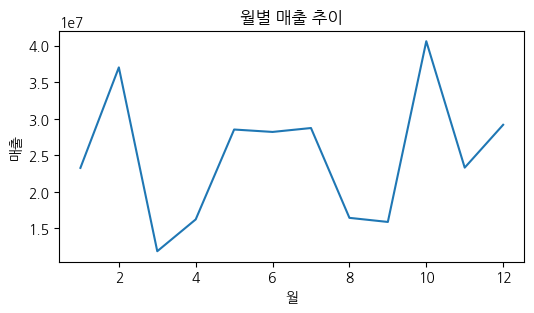

In [26]:
plt.figure(figsize=(6,3))
plt.plot(df_1.index , df_1.values)
plt.title('월별 매출 추이')
plt.xlabel('월')
plt.ylabel('매출')
plt.savefig('차트1.jpg')
plt.show()

---
## 2. 막대 그래프 - `bar`

**카테고리별 비교**에 가장 많이 씁니다.


In [30]:
# 카테고리별로 매출 총합을 가져와라. 
df_2 = df.groupby('카테고리')['매출'].sum()

In [41]:
df_2 = df_2.sort_values(ascending=False)

In [42]:
df_2

카테고리
컴퓨터     209680000
주변기기     29420000
웨어러블     25920000
음향       17965000
저장장치     12065000
액세서리      4378000
Name: 매출, dtype: int64

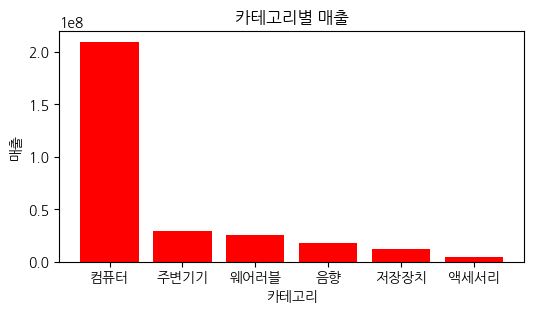

In [43]:
plt.figure(figsize=(6,3))
plt.bar(df_2.index, df_2.values, color='red')
plt.title('카테고리별 매출')
plt.xlabel('카테고리')
plt.ylabel('매출')
plt.show()

---
## 3. 산점도 - `scatter`

**두 변수의 관계**를 볼 때 사용합니다.


In [ ]:
# 2개의 컬럼의 관계를 나타낼때 사용한다.

In [44]:
df.head()

,주문번호,고객ID,상품코드,수량,상품명,카테고리,단가,매출,고객명,성별,연령,지역,가입일,회원등급,년도,월,날짜,요일
주문일자,,,,,,,,,,,,,,,,,,
2024-01-02,ORD00001,C019,P001,3,노트북,컴퓨터,1350000,4050000,엄정화,여,54,대전,2022-04-01,골드,2024,1,2,1
2024-01-03,ORD00002,C028,P013,3,이어폰,음향,55000,165000,김유정,여,53,서울,2022-05-16,실버,2024,1,3,2
2024-01-04,ORD00003,C026,P002,3,무선마우스,주변기기,35000,105000,김민수,여,27,경기,2022-05-06,실버,2024,1,4,3
2024-01-05,ORD00004,C037,P004,2,27인치모니터,컴퓨터,450000,900000,고윤정,여,54,경기,2022-06-30,골드,2024,1,5,4
2024-01-06,ORD00005,C026,P014,2,태블릿,컴퓨터,680000,1360000,김민수,여,27,경기,2022-05-06,실버,2024,1,6,5


In [45]:
# 두 컬럼간의 관계 분석은 => 상관분석을 이용한다.
# 상관분석이란 =>  -1 ~ 1 사이의 숫자가 나온다.
# 1에 가까울수록 두 컬럼은 비례관계이고
# -1에 가까울수록 두 컬럼은 반비례관계이고
# 0에 가까울수록 두 컬럼은 서로 관계 없다.
# 이렇게 분석하는것을 상관분석이라고 한다. 

In [47]:
# 단가와 매출의 관계를 분석해줘 => 단가 컬럼, 매출 컬럼이 먼저 있어야 한다.

In [51]:
df[ ['단가','매출'] ].corr()

,단가,매출
단가,1.000000,0.804983
매출,0.804983,1.000000


In [ ]:
# 상관계수는 0.80 입니다. 

In [53]:
df_3 = df[ ['단가','매출'] ]

In [54]:
df_3

,단가,매출
주문일자,,
2024-01-02,1350000,4050000
2024-01-03,55000,165000
2024-01-04,35000,105000
2024-01-05,450000,900000
2024-01-06,680000,1360000
...,...,...
2024-12-30,65000,130000
2024-12-30,450000,450000
2024-12-31,95000,285000


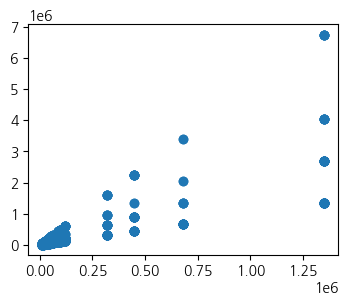

In [59]:
plt.figure(figsize=(4,3))
plt.scatter( df_3['단가'] , df_3['매출'] )
plt.show()

---
## 4. 차트 꾸미기 기본

| 함수 | 용도 |
|------|------|
| `figsize=(가로, 세로)` | 차트 크기 |
| `title()` | 제목 |
| `xlabel()` / `ylabel()` | 축 이름 |
| `legend()` | 범례 |
| `grid()` | 격자 |
| `color="색"` | 색상 |


In [ ]:
# 아래에 코드를 작성하세요


---
## 실습문제

> 공통 준비:
> ```python
> import matplotlib.pyplot as plt
> import platform
> if platform.system() == "Darwin":
>     plt.rcParams["font.family"] = "AppleGothic"
> elif platform.system() == "Windows":
>     plt.rcParams["font.family"] = "Malgun Gothic"
> plt.rcParams["axes.unicode_minus"] = False
> ```

### 문제 1. 카테고리별 매출 막대그래프

`products`와 `orders_q*` 데이터를 합친 후 카테고리별 매출을 내림차순 막대그래프로 그리세요.


In [ ]:
# 아래에 코드를 작성하세요


### 문제 2. 월별 매출 선그래프

월별 매출 합계를 선 그래프로 그리세요.


In [ ]:
# 아래에 코드를 작성하세요


### 문제 3. 지역별 고객 수 가로 막대

`customers`에서 지역별 고객 수를 구하고, 가로 막대그래프로 그리세요.


In [ ]:
# 아래에 코드를 작성하세요


### 문제 4. 상품 Top 10 가로 막대

상품명별 매출 합계 상위 10개를 가로 막대 그래프로 그리세요.


In [ ]:
# 아래에 코드를 작성하세요
